**Initial setup for all of continental USA, not just Florida anymore.**
- 14 May 2026

In [2]:
# --- Cell 1: Load POUS and print basic checks ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# File path for the county x storm event dataset
pous_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_raw\POUS.csv"

# Load POUS
pous = pd.read_csv(pous_path)

# Standardise FIPS as strings with leading zeros preserved
pous["CountyFIPS"] = pous["CountyFIPS"].astype(str).str.zfill(5)

# Parse event_start as datetime
pous["event_start"] = pd.to_datetime(pous["event_start"])

# Basic sanity checks
print("POUS shape:", pous.shape)
print("\nColumns:")
print(pous.columns.tolist())

print("\nDtypes:")
print(pous.dtypes)

print("\nHead:")
print(pous.head())

print("\nDate range:")
print("Start:", pous["event_start"].min())
print("End:  ", pous["event_start"].max())

print("\nUnique counties:", pous["CountyFIPS"].nunique())
print("Unique storms:   ", pous["storm"].nunique())
print("Unique events:   ", pous.groupby(["CountyFIPS", "storm"]).ngroups)

print("\nMissing values per column:")
print(pous.isna().sum())

POUS shape: (1040, 13)

Columns:
['event_start', 'CountyFIPS', 'county_pop', 'pre_outage_tracked_customers', 'days_since_data_start', 'duration_hours', 'n_periods', 'integral', 'pop_hours_supply_lost', 'storm', 'duration_days', 'year', 'month']

Dtypes:
event_start                     datetime64[us]
CountyFIPS                                 str
county_pop                               int64
pre_outage_tracked_customers           float64
days_since_data_start                  float64
duration_hours                           int64
n_periods                                int64
integral                               float64
pop_hours_supply_lost                  float64
storm                                      str
duration_days                          float64
year                                     int64
month                                    int64
dtype: object

Head:
          event_start CountyFIPS  county_pop  pre_outage_tracked_customers  \
0 2017-06-21 16:00:00      54001    

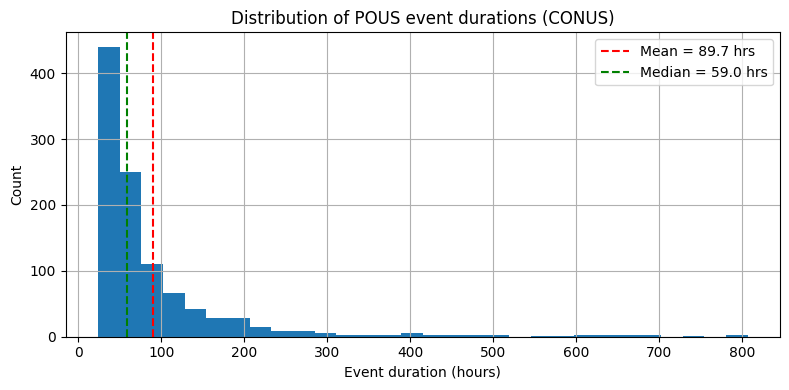

Duration summary:
count    1040.000000
mean       89.707692
std        99.504640
min        24.000000
25%        37.750000
50%        59.000000
75%        98.250000
max       807.000000
Name: duration_hours, dtype: float64

Mean duration:   89.71 hrs
Median duration: 59.00 hrs
Std dev:         99.50 hrs


In [3]:
# --- Cell 2: Histogram of event duration ---

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

# Event duration distribution
pous["duration_hours"].hist(bins=30)

# Summary statistics for the plot
mean_val = pous["duration_hours"].mean()
median_val = pous["duration_hours"].median()
std_val = pous["duration_hours"].std()

# Reference lines
plt.axvline(mean_val, linestyle="--", color="red", label=f"Mean = {mean_val:.1f} hrs")
plt.axvline(median_val, linestyle="--", color="green", label=f"Median = {median_val:.1f} hrs")

plt.xlabel("Event duration (hours)")
plt.ylabel("Count")
plt.title("Distribution of POUS event durations (CONUS)")
plt.legend()
plt.tight_layout()
plt.show()

print("Duration summary:")
print(pous["duration_hours"].describe())
print(f"\nMean duration:   {mean_val:.2f} hrs")
print(f"Median duration: {median_val:.2f} hrs")
print(f"Std dev:         {std_val:.2f} hrs")

In [4]:
# --- Cell 3: Quick state-level event counts (useful CONUS sanity check) ---

# FIPS -> state code mapping
fips_to_state = {
    "01":"AL","02":"AK","04":"AZ","05":"AR","06":"CA","08":"CO","09":"CT","10":"DE",
    "11":"DC","12":"FL","13":"GA","15":"HI","16":"ID","17":"IL","18":"IN","19":"IA",
    "20":"KS","21":"KY","22":"LA","23":"ME","24":"MD","25":"MA","26":"MI","27":"MN",
    "28":"MS","29":"MO","30":"MT","31":"NE","32":"NV","33":"NH","34":"NJ","35":"NM",
    "36":"NY","37":"NC","38":"ND","39":"OH","40":"OK","41":"OR","42":"PA","44":"RI",
    "45":"SC","46":"SD","47":"TN","48":"TX","49":"UT","50":"VT","51":"VA","53":"WA",
    "54":"WV","55":"WI","56":"WY"
}

# Extract state FIPS from county code
pous["state_fips"] = pous["CountyFIPS"].str[:2]
pous["state"] = pous["state_fips"].map(fips_to_state)

state_counts = (
    pous.groupby(["state", "state_fips"])
    .size()
    .reset_index(name="n_events")
    .sort_values("n_events", ascending=False)
)

print("Top 10 states by number of POUS events:")
print(state_counts.head(10).to_string(index=False))

fl = state_counts.loc[state_counts["state"] == "FL", "n_events"]
if not fl.empty:
    print(f"\nFlorida event count: {int(fl.iloc[0])}")

Top 10 states by number of POUS events:
state state_fips  n_events
   GA         13       179
   LA         22       162
   NC         37       132
   FL         12        99
   VA         51        85
   MS         28        79
   AL         01        63
   TX         48        56
   SC         45        37
   AR         05        23

Florida event count: 99


In [ ]:
# --- Cell : Imports, paths, POUS load, parquet dataset setup ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Efficient parquet access for the very large CONUS time series file
import pyarrow.dataset as ds

# File paths
ts_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_raw\timeseries.pq"
pous_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_raw\POUS.csv"

# Load POUS event-level file so we can sample county-storm windows to inspect
pous = pd.read_csv(pous_path)
pous["CountyFIPS"] = pous["CountyFIPS"].astype(str).str.zfill(5)
pous["event_start"] = pd.to_datetime(pous["event_start"])

print("Loaded POUS shape:", pous.shape)
print("Event start range:", pous["event_start"].min(), "to", pous["event_start"].max())
print("Unique counties:", pous["CountyFIPS"].nunique())
print("Unique storms:", pous["storm"].nunique())

# Create the parquet dataset object once; do not load the full 160M-row file into memory
ts_dataset = ds.dataset(ts_path, format="parquet")

# Helpful check on the parquet schema
print("\nParquet schema fields:")
print(ts_dataset.schema.names)

def load_time_series_window(county_fips, event_start, days_before=3, days_after=14):
    """
    Load a small time window for one county directly from the parquet file.

    Important:
    - The parquet file may reconstruct RecordDateTime / CountyFIPS as an index
      when converted back to pandas.
    - We therefore reset the index if those fields are not already columns.
    """
    event_start = pd.Timestamp(event_start)
    window_start = event_start - pd.Timedelta(days=days_before)
    window_end = event_start + pd.Timedelta(days=days_after)

    # Filter the large parquet dataset before materialising into pandas
    filt = (
        (ds.field("CountyFIPS") == county_fips) &
        (ds.field("RecordDateTime") >= window_start.to_pydatetime()) &
        (ds.field("RecordDateTime") <= window_end.to_pydatetime())
    )

    table = ts_dataset.to_table(
        columns=["RecordDateTime", "CountyFIPS", "OutageFraction"],
        filter=filt
    )

    out = table.to_pandas()

    if out.empty:
        return out

    # When pandas reconstructs the parquet index, these fields may not be columns yet
    if "RecordDateTime" not in out.columns or "CountyFIPS" not in out.columns:
        out = out.reset_index()

    out["RecordDateTime"] = pd.to_datetime(out["RecordDateTime"])
    out["CountyFIPS"] = out["CountyFIPS"].astype(str).str.zfill(5)
    out = out.sort_values("RecordDateTime").reset_index(drop=True)

    return out

Loaded POUS shape: (1040, 13)
Event start range: 2017-06-21 16:00:00 to 2022-10-01 02:00:00
Unique counties: 675
Unique storms: 35

Parquet schema fields:
['OutageFraction', 'CustomersTracked', 'RecordDateTime', 'CountyFIPS']


Random sample of 20 events:
        storm CountyFIPS         event_start  duration_hours
2017242N16333      13091 2017-09-11 14:00:00              58
2020233N14313      22045 2020-08-27 07:00:00              56
2018146N19273      21039 2018-05-27 13:00:00              34
2017228N14314      28053 2017-09-01 00:00:00              24
2020233N14313      05147 2020-08-28 01:00:00              70
2021239N17281      22117 2021-08-29 21:00:00             240
2018280N18273      13037 2018-10-10 21:00:00             195
2018280N18273      13023 2018-10-11 04:00:00              64
2019299N25265      28065 2019-10-26 13:00:00              53
2018280N18273      51073 2018-10-12 01:00:00              96
2020233N14313      05027 2020-08-27 17:00:00              56
2020211N13306      37187 2020-08-04 09:00:00              37
2020299N18277      37035 2020-10-29 14:00:00              58
2020279N16284      28113 2020-10-10 05:00:00              37
2018242N13343      51077 2018-09-17 02:00:00             

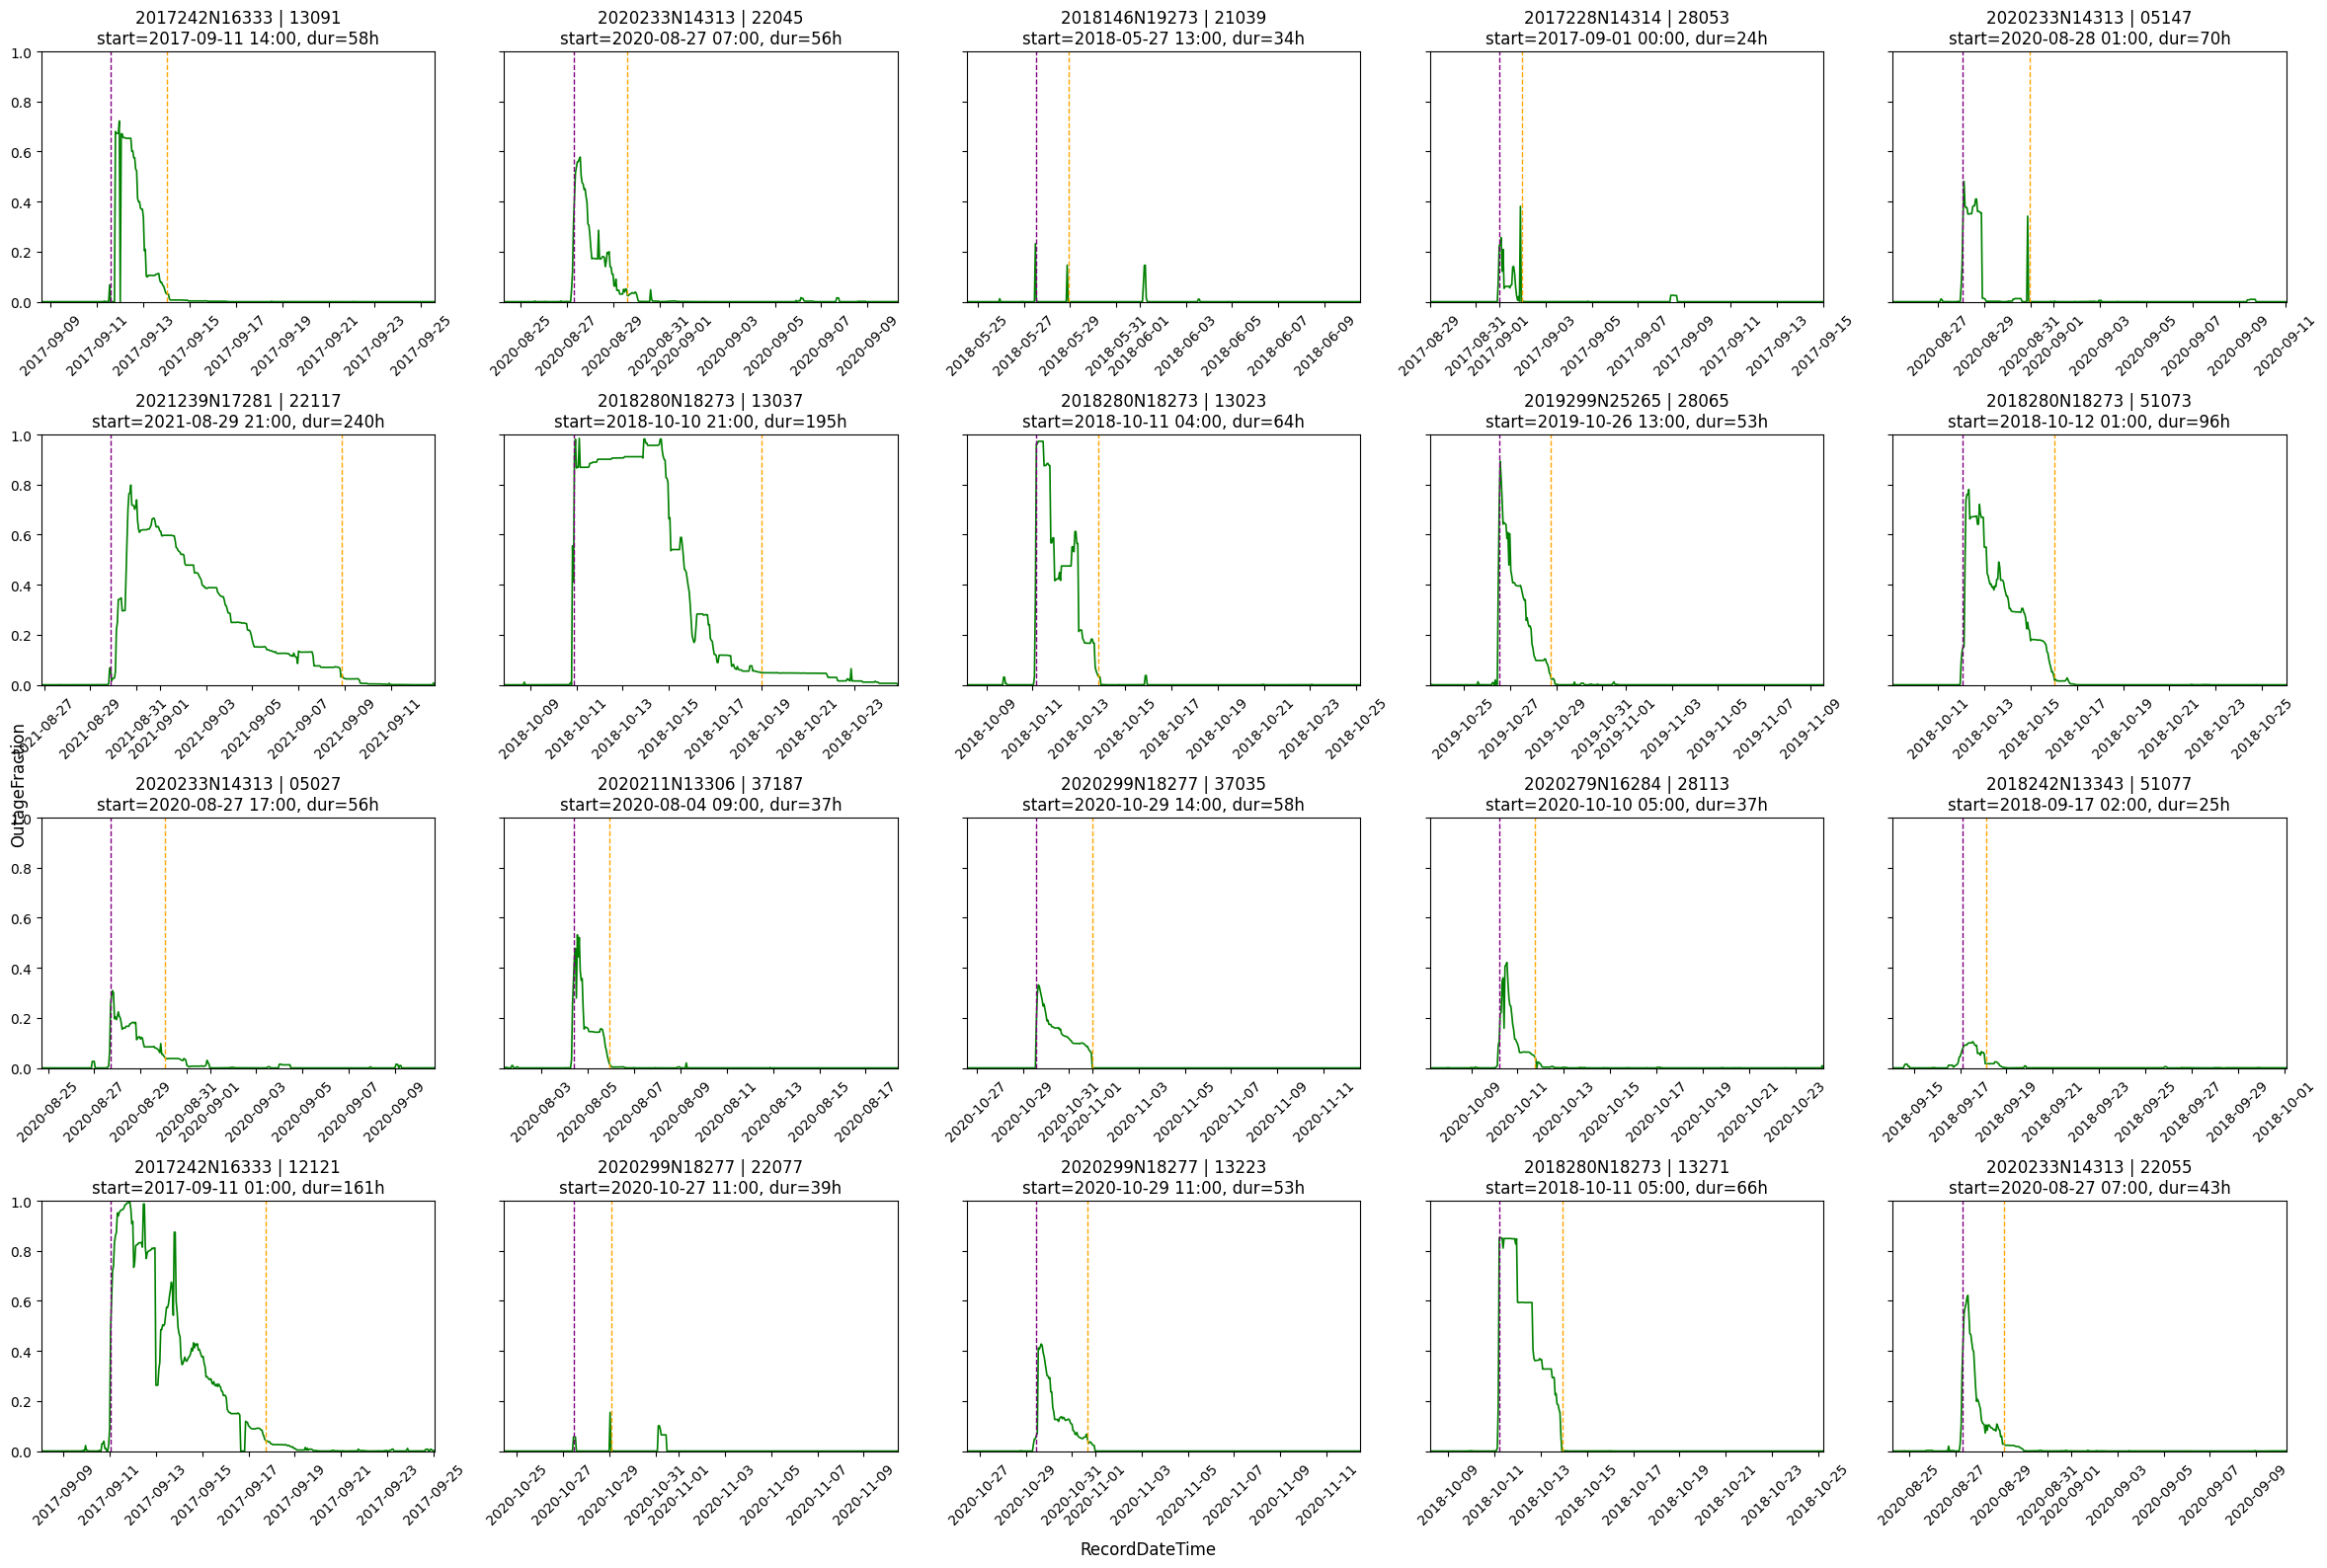


Plotted 20 county-event time series windows.


In [ ]:
# --- Cell : Plot 20 random time series windows (4 x 5 grid) ---

# Toggle window type:
#   "fixed" = plot a fixed time window after event start
#   "event" = plot only until the end of the event using POUS duration_hours
WINDOW_MODE = "fixed"   # change to "event" if you want to plot to the event end

# Fixed-window settings (used only when WINDOW_MODE == "fixed")
days_before = 3
days_after = 14

# Randomly sample 20 county-storm events to inspect
sample_events = pous.sample(n=20, random_state=42).reset_index(drop=True)

print("Random sample of 20 events:")
print(sample_events[["storm", "CountyFIPS", "event_start", "duration_hours"]].to_string(index=False))

fig, axes = plt.subplots(4, 5, figsize=(24, 16), sharey=True)
axes = axes.ravel()

for ax in axes:
    ax.set_visible(False)

n_plotted = 0

for ax, (_, row) in zip(axes, sample_events.iterrows()):
    county_fips = row["CountyFIPS"]
    event_start = row["event_start"]
    storm = row["storm"]
    duration_hours = row["duration_hours"]

    # Choose end of plotted window
    if WINDOW_MODE == "fixed":
        window_start = event_start - pd.Timedelta(days=days_before)
        window_end = event_start + pd.Timedelta(days=days_after)
    elif WINDOW_MODE == "event":
        window_start = event_start - pd.Timedelta(days=days_before)
        window_end = event_start + pd.Timedelta(hours=float(duration_hours))
    else:
        raise ValueError("WINDOW_MODE must be 'fixed' or 'event'.")

    g = load_time_series_window(
        county_fips=county_fips,
        event_start=event_start,
        days_before=days_before,
        days_after=(days_after if WINDOW_MODE == "fixed" else int(np.ceil(duration_hours / 24)) + 1),
    )

    ax.set_visible(True)
    ax.set_ylim(0.0, 1.0)
    ax.set_xlim(window_start, window_end)

    if g.empty:
        ax.set_title(f"{storm} | {county_fips}\n(no data returned)")
        continue

    # Plot outage fraction over time
    ax.plot(g["RecordDateTime"], g["OutageFraction"], color="green", linewidth=1.2)

    # Event start line
    ax.axvline(event_start, color="purple", linestyle="--", linewidth=1)

    # Event end line (based on POUS duration)
    event_end = event_start + pd.Timedelta(hours=float(duration_hours))
    ax.axvline(event_end, color="orange", linestyle="--", linewidth=1)

    ax.set_title(
        f"{storm} | {county_fips}\n"
        f"start={event_start.strftime('%Y-%m-%d %H:%M')}, dur={duration_hours:.0f}h"
    )
    ax.tick_params(axis="x", labelrotation=45)

    n_plotted += 1

fig.supylabel("OutageFraction")
fig.supxlabel("RecordDateTime")
plt.tight_layout()
plt.show()

print(f"\nPlotted {n_plotted} county-event time series windows.")

In [8]:
# --- Cell 5: Build a CONUS sample source_df from the parquet time series ---

# This cell loads only 20 sampled county-storm windows from the large parquet file.
# It avoids reading the full ~160M-row file into memory.

import pandas as pd
import numpy as np

# Sample 20 event rows from POUS for inspection
sample_events = pous.sample(n=20, random_state=42).reset_index(drop=True)

print("Random sample of 20 POUS events:")
print(sample_events[["storm", "CountyFIPS", "event_start", "duration_hours"]].to_string(index=False))

def load_time_series_window(county_fips, event_start, days_before=3, days_after=14):
    """
    Load a small time window for one county directly from the parquet dataset.
    Returns a pandas DataFrame with:
      RecordDateTime, CountyFIPS, OutageFraction, CustomersTracked (if present)
    """
    event_start = pd.Timestamp(event_start)
    window_start = event_start - pd.Timedelta(days=days_before)
    window_end = event_start + pd.Timedelta(days=days_after)

    filt = (
        (ds.field("CountyFIPS") == county_fips) &
        (ds.field("RecordDateTime") >= window_start.to_pydatetime()) &
        (ds.field("RecordDateTime") <= window_end.to_pydatetime())
    )

    # Load only the columns we need for cleaning / plotting
    cols = ["RecordDateTime", "CountyFIPS", "OutageFraction", "CustomersTracked"]
    available_cols = [c for c in cols if c in ts_dataset.schema.names]

    table = ts_dataset.to_table(columns=available_cols, filter=filt)
    out = table.to_pandas()

    if out.empty:
        return out

    # Parquet may reconstruct index-like fields depending on how the file was written
    if "RecordDateTime" not in out.columns or "CountyFIPS" not in out.columns:
        out = out.reset_index()

    out["RecordDateTime"] = pd.to_datetime(out["RecordDateTime"])
    out["CountyFIPS"] = out["CountyFIPS"].astype(str).str.zfill(5)
    out = out.sort_values("RecordDateTime").reset_index(drop=True)

    return out

# Build a single inspection dataframe from the 20 sampled windows
pieces = []

for _, row in sample_events.iterrows():
    g = load_time_series_window(
        county_fips=row["CountyFIPS"],
        event_start=row["event_start"],
        days_before=3,
        days_after=14
    )

    if g.empty:
        continue

    # Add event metadata so the grouping logic matches the Florida notebook style
    g = g.copy()
    g["storm"] = row["storm"]
    g["event_start"] = pd.Timestamp(row["event_start"])
    g["duration_hours"] = row["duration_hours"]

    # Match the earlier convention: county + event_start
    g["event_id"] = g["CountyFIPS"].astype(str) + "_" + g["event_start"].dt.strftime("%Y-%m-%d %H:%M:%S")

    pieces.append(g)

source_df = pd.concat(pieces, ignore_index=True)

print("\nCombined sample source_df shape:", source_df.shape)
print(source_df.head())
print("\nColumns:")
print(source_df.columns.tolist())

Random sample of 20 POUS events:
        storm CountyFIPS         event_start  duration_hours
2017242N16333      13091 2017-09-11 14:00:00              58
2020233N14313      22045 2020-08-27 07:00:00              56
2018146N19273      21039 2018-05-27 13:00:00              34
2017228N14314      28053 2017-09-01 00:00:00              24
2020233N14313      05147 2020-08-28 01:00:00              70
2021239N17281      22117 2021-08-29 21:00:00             240
2018280N18273      13037 2018-10-10 21:00:00             195
2018280N18273      13023 2018-10-11 04:00:00              64
2019299N25265      28065 2019-10-26 13:00:00              53
2018280N18273      51073 2018-10-12 01:00:00              96
2020233N14313      05027 2020-08-27 17:00:00              56
2020211N13306      37187 2020-08-04 09:00:00              37
2020299N18277      37035 2020-10-29 14:00:00              58
2020279N16284      28113 2020-10-10 05:00:00              37
2018242N13343      51077 2018-09-17 02:00:00        

Valid / invalid counts:
is_valid
True     17
False     3
Name: count, dtype: int64

       max_outage  hours_above_thresh
count   20.000000           20.000000
mean     0.578779           44.900000
std      0.284225           47.764664
min      0.105101            0.000000
25%      0.368895           16.500000
50%      0.555144           26.500000
75%      0.811785           62.750000
max      0.993807          155.000000


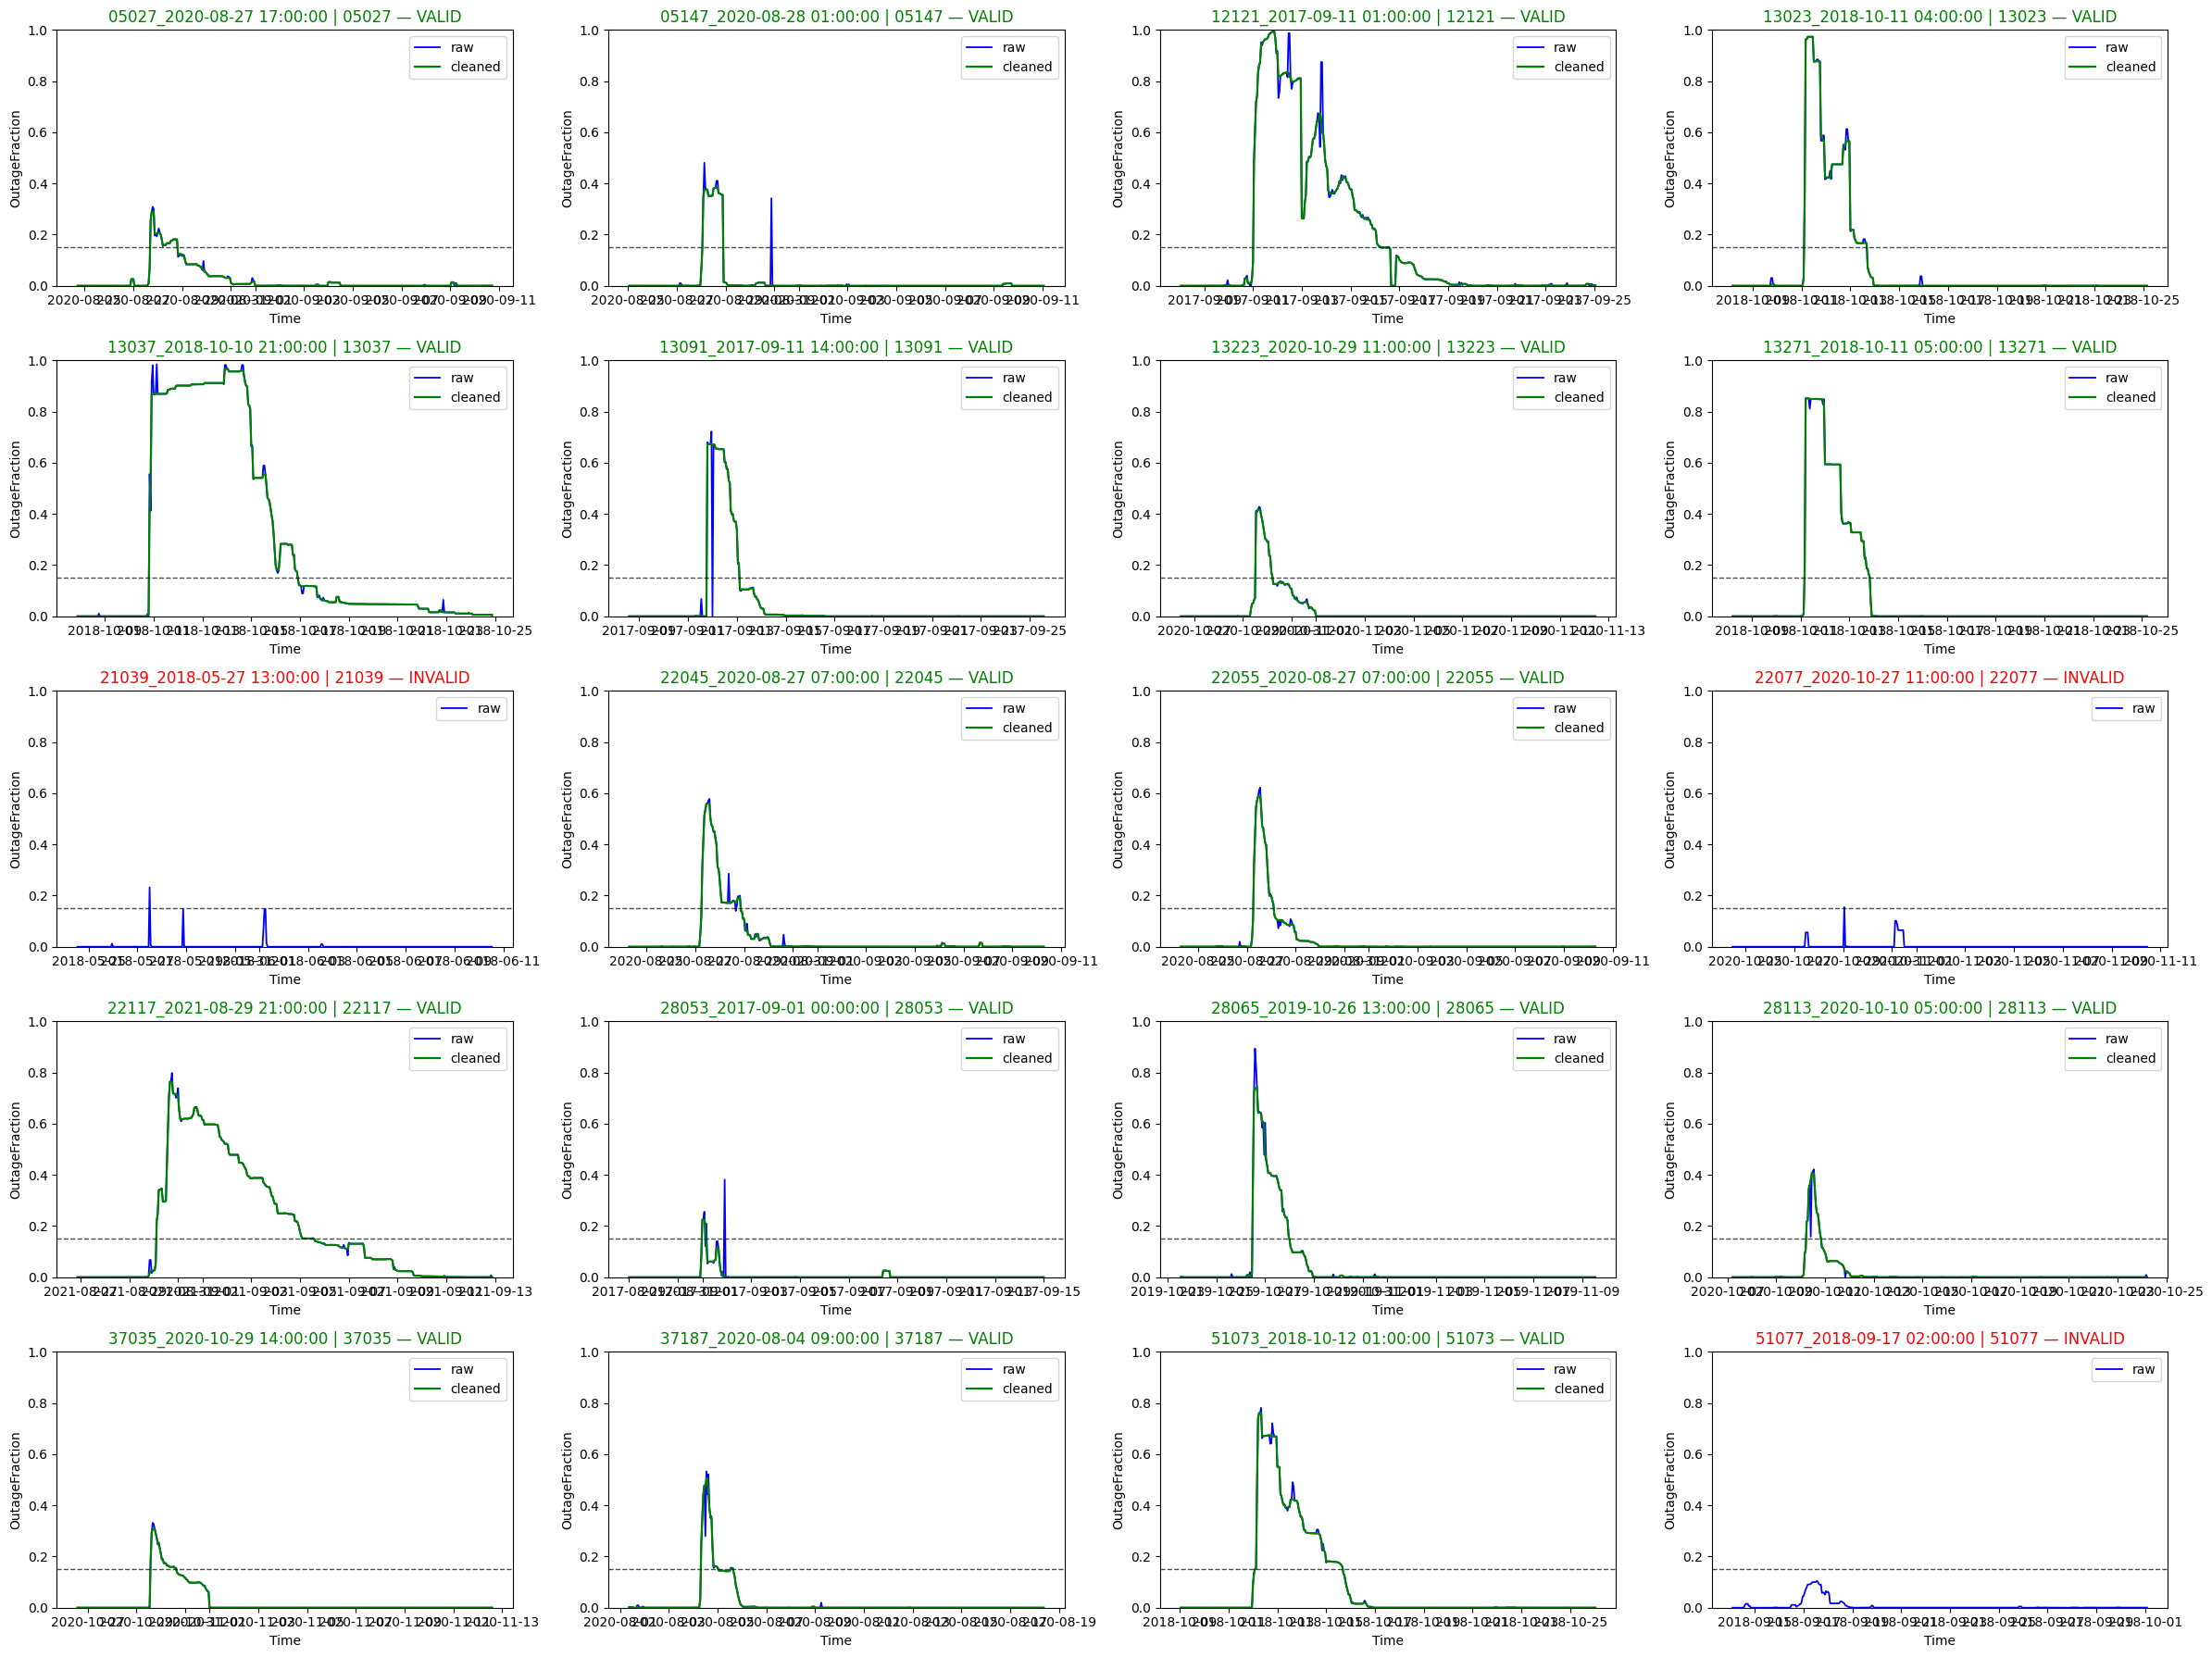

In [9]:
# --- Cell 6: Valid/invalid classification + smoothing + 20-panel plot for CONUS sample ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Same logic as the Florida notebook
peak_thresh = 0.15
min_hours_above = 5

med_window = 5
max_short_run = 3
abs_dev_thresh = 0.15
rel_dev_scale = 0.35

# Keep only the columns needed for cleaning / plotting
source_df = source_df.copy()
source_df["RecordDateTime"] = pd.to_datetime(source_df["RecordDateTime"])
source_df["event_start"] = pd.to_datetime(source_df["event_start"])
source_df["CountyFIPS"] = source_df["CountyFIPS"].astype(str).str.zfill(5)

# Event-level validity mask
event_metrics = (
    source_df.groupby(["event_id", "CountyFIPS"], as_index=False)
    .agg(
        max_outage=("OutageFraction", "max"),
        hours_above_thresh=("OutageFraction", lambda s: (s > peak_thresh).sum()),
    )
)

event_metrics["is_valid"] = (
    (event_metrics["max_outage"] >= peak_thresh) &
    (event_metrics["hours_above_thresh"] >= min_hours_above)
)

print("Valid / invalid counts:")
print(event_metrics["is_valid"].value_counts(dropna=False))
print()
print(event_metrics[["max_outage", "hours_above_thresh"]].describe())

def clean_valid_outage_series(g):
    """
    Same cleaning logic as the Florida notebook:
    - 5-hour rolling median
    - anomaly threshold based on absolute + relative deviation
    - interpolate only short anomalous runs
    - final 5-hour rolling median
    """
    g = g.sort_values("RecordDateTime").copy().reset_index(drop=True)
    s = g["OutageFraction"].astype(float).clip(0, 1)

    # Baseline
    med = s.rolling(window=med_window, center=True, min_periods=1).median()

    # Anomaly detection
    dev = (s - med).abs()
    thresh = np.maximum(abs_dev_thresh, rel_dev_scale * med)
    anomaly = dev > thresh

    # Identify runs of anomalous values
    run_id = (anomaly != anomaly.shift()).cumsum()
    run_len = anomaly.groupby(run_id).transform("sum")
    short_anom = anomaly & (run_len <= max_short_run)

    # Mask and interpolate short runs only
    repaired = s.mask(short_anom, np.nan)
    repaired_filled = repaired.copy()
    was_interpolated = pd.Series(False, index=g.index)

    run_id_np = run_id.to_numpy()
    short_run_ids = pd.unique(run_id[short_anom])

    for rid in short_run_ids:
        pos = np.flatnonzero(run_id_np == rid)
        if len(pos) == 0 or len(pos) > max_short_run:
            continue

        left = pos[0] - 1
        right = pos[-1] + 1
        if left < 0 or right >= len(g):
            continue

        left_val = repaired.iloc[left]
        right_val = repaired.iloc[right]
        if pd.isna(left_val) or pd.isna(right_val):
            continue

        repaired_filled.iloc[pos] = np.linspace(left_val, right_val, len(pos) + 2)[1:-1]
        was_interpolated.iloc[pos] = True

    # Final smoothing
    cleaned = repaired_filled.rolling(window=med_window, center=True, min_periods=1).median()

    g["of_rolling_median"] = med
    g["of_anomaly"] = anomaly
    g["of_short_anomaly"] = short_anom
    g["outageFraction_repaired"] = repaired_filled
    g["outageFraction_clean"] = cleaned
    g["outageFraction_was_interpolated"] = was_interpolated

    return g

# Only clean valid groups
valid_keys = set(
    event_metrics.loc[event_metrics["is_valid"], ["event_id", "CountyFIPS"]]
    .itertuples(index=False, name=None)
)

groups = (
    source_df[["event_id", "CountyFIPS"]]
    .drop_duplicates()
    .sort_values(["event_id", "CountyFIPS"])
    .reset_index(drop=True)
)

# Plot a 20-panel chunk
chunk = 1
plots_per_chunk = 20

start = (chunk - 1) * plots_per_chunk
end = min(start + plots_per_chunk, len(groups))

fig, axes = plt.subplots(5, 4, figsize=(24, 18))
axes = axes.ravel()

for ax in axes:
    ax.set_visible(False)

for ax, (_, row) in zip(axes, groups.iloc[start:end].iterrows()):
    event_id = row["event_id"]
    county_fips = row["CountyFIPS"]

    g_raw = source_df[
        (source_df["event_id"] == event_id) &
        (source_df["CountyFIPS"] == county_fips)
    ].sort_values("RecordDateTime").copy()

    is_valid = (event_id, county_fips) in valid_keys
    label = "VALID" if is_valid else "INVALID"
    title_color = "green" if is_valid else "red"

    ax.set_visible(True)

    # Raw series
    ax.plot(
        g_raw["RecordDateTime"],
        g_raw["OutageFraction"],
        color="blue",
        linewidth=1.3,
        label="raw"
    )

    # Cleaned series only for valid events
    if is_valid:
        g_clean = clean_valid_outage_series(g_raw)
        ax.plot(
            g_clean["RecordDateTime"],
            g_clean["outageFraction_clean"],
            color="green",
            linewidth=1.6,
            label="cleaned"
        )

    ax.axhline(peak_thresh, linestyle="--", linewidth=1, color="black", alpha=0.7)

    ax.set_title(f"{event_id} | {county_fips} — {label}", color=title_color)
    ax.set_xlabel("Time")
    ax.set_ylabel("OutageFraction")
    ax.set_ylim(0.0, 1.0)
    ax.legend(loc="best")

plt.tight_layout()
plt.show()

In [10]:
# --- Cell : Full CONUS valid / invalid classification from POUS + parquet time series ---

import pandas as pd
import numpy as np
from tqdm.auto import tqdm

# Threshold / event rules (same as the Florida notebook)
peak_thresh = 0.15
min_hours_above = 5

# Helper to load the exact event window from the large parquet time series
# This is used to compute the event validity metrics across all POUS events.
def load_event_window_from_pq(county_fips, event_start, event_end, pad_before_days=0, pad_after_days=0):
    """
    Load a small time window for one county-event directly from the parquet dataset.
    Uses the global ts_dataset created earlier in the notebook.
    """
    event_start = pd.Timestamp(event_start)
    event_end = pd.Timestamp(event_end)

    window_start = event_start - pd.Timedelta(days=pad_before_days)
    window_end = event_end + pd.Timedelta(days=pad_after_days)

    filt = (
        (ds.field("CountyFIPS") == county_fips) &
        (ds.field("RecordDateTime") >= window_start.to_pydatetime()) &
        (ds.field("RecordDateTime") <= window_end.to_pydatetime())
    )

    table = ts_dataset.to_table(
        columns=["RecordDateTime", "CountyFIPS", "OutageFraction"],
        filter=filt
    )

    out = table.to_pandas()

    if out.empty:
        return out

    if "RecordDateTime" not in out.columns or "CountyFIPS" not in out.columns:
        out = out.reset_index()

    out["RecordDateTime"] = pd.to_datetime(out["RecordDateTime"])
    out["CountyFIPS"] = out["CountyFIPS"].astype(str).str.zfill(5)
    out = out.sort_values("RecordDateTime").reset_index(drop=True)

    return out

# Build POUS event identifiers to match the event-level convention
pous = pous.copy()
pous["CountyFIPS"] = pous["CountyFIPS"].astype(str).str.zfill(5)
pous["event_start"] = pd.to_datetime(pous["event_start"])
pous["event_id"] = (
    pous["CountyFIPS"].astype(str) + "_" +
    pous["event_start"].dt.strftime("%Y-%m-%d %H:%M:%S")
)

# Scan every county-event row in POUS and compute validity metrics from the time series
event_rows = []

for row in tqdm(pous.itertuples(index=False), total=len(pous), desc="Scanning POUS events"):
    county_fips = str(row.CountyFIPS).zfill(5)
    event_start = pd.Timestamp(row.event_start)
    duration_hours = float(row.duration_hours)
    event_end = event_start + pd.Timedelta(hours=duration_hours)

    g = load_event_window_from_pq(
        county_fips=county_fips,
        event_start=event_start,
        event_end=event_end,
        pad_before_days=0,
        pad_after_days=0
    )

    if g.empty:
        max_outage = np.nan
        hours_above_thresh = 0
        n_ts_points = 0
    else:
        s = g["OutageFraction"].astype(float).clip(0, 1)
        max_outage = float(s.max())
        hours_above_thresh = int((s > peak_thresh).sum())
        n_ts_points = int(len(g))

    event_rows.append({
        "event_id": row.event_id,
        "CountyFIPS": county_fips,
        "storm": row.storm,
        "event_start": event_start,
        "duration_hours": duration_hours,
        "max_outage": max_outage,
        "hours_above_thresh": hours_above_thresh,
        "n_ts_points": n_ts_points,
    })

event_metrics = pd.DataFrame(event_rows)

# Same validity rule as before
event_metrics["is_valid"] = (
    (event_metrics["max_outage"] >= peak_thresh) &
    (event_metrics["hours_above_thresh"] >= min_hours_above)
)

print("Valid / invalid counts:")
print(event_metrics["is_valid"].value_counts(dropna=False))
print()
print(event_metrics[["max_outage", "hours_above_thresh", "duration_hours"]].describe())

# Valid / rejected event lists
valid_df = event_metrics.loc[event_metrics["is_valid"], ["event_id", "CountyFIPS"]].copy()
rejected = event_metrics.loc[~event_metrics["is_valid"]].copy()

print("\nTotal raw events:", len(event_metrics))
print("Valid events:    ", len(valid_df))
print("Rejected events: ", len(rejected))

# Storm-level before / after summary
raw_groups = event_metrics[["event_id", "CountyFIPS", "storm"]].drop_duplicates()

valid_groups = raw_groups.merge(valid_df, on=["event_id", "CountyFIPS"], how="inner")

raw_counts = raw_groups["storm"].value_counts().sort_index()
valid_counts = valid_groups["storm"].value_counts().sort_index()

summary = pd.DataFrame({
    "before_filtering": raw_counts,
    "after_filtering": valid_counts
}).fillna(0)

summary["after_filtering"] = summary["after_filtering"].astype(int)
summary["removed"] = summary["before_filtering"] - summary["after_filtering"]

print("\nEvent-county counts per storm:")
print(summary.sort_values("before_filtering", ascending=False))

fully_removed = summary[summary["after_filtering"] == 0]

print("\nStorms completely removed:")
print(fully_removed if not fully_removed.empty else "None")

c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Scanning POUS events: 100%|██████████| 1040/1040 [00:42<00:00, 24.52it/s]

Valid / invalid counts:
is_valid
True     813
False    227
Name: count, dtype: int64

        max_outage  hours_above_thresh  duration_hours
count  1040.000000         1040.000000     1040.000000
mean      0.534432           55.095192       89.707692
std       0.315298           83.108482       99.504640
min       0.050290            0.000000       24.000000
25%       0.255835            7.000000       37.750000
50%       0.479454           27.500000       59.000000
75%       0.839907           69.000000       98.250000
max       1.000000          594.000000      807.000000

Total raw events: 1040
Valid events:     813
Rejected events:  227

Event-county counts per storm:
               before_filtering  after_filtering  removed
storm                                                    
2018280N18273               161              151       10
2017242N16333               137              127       10
2020299N18277               111               96       15
2020211N13306                

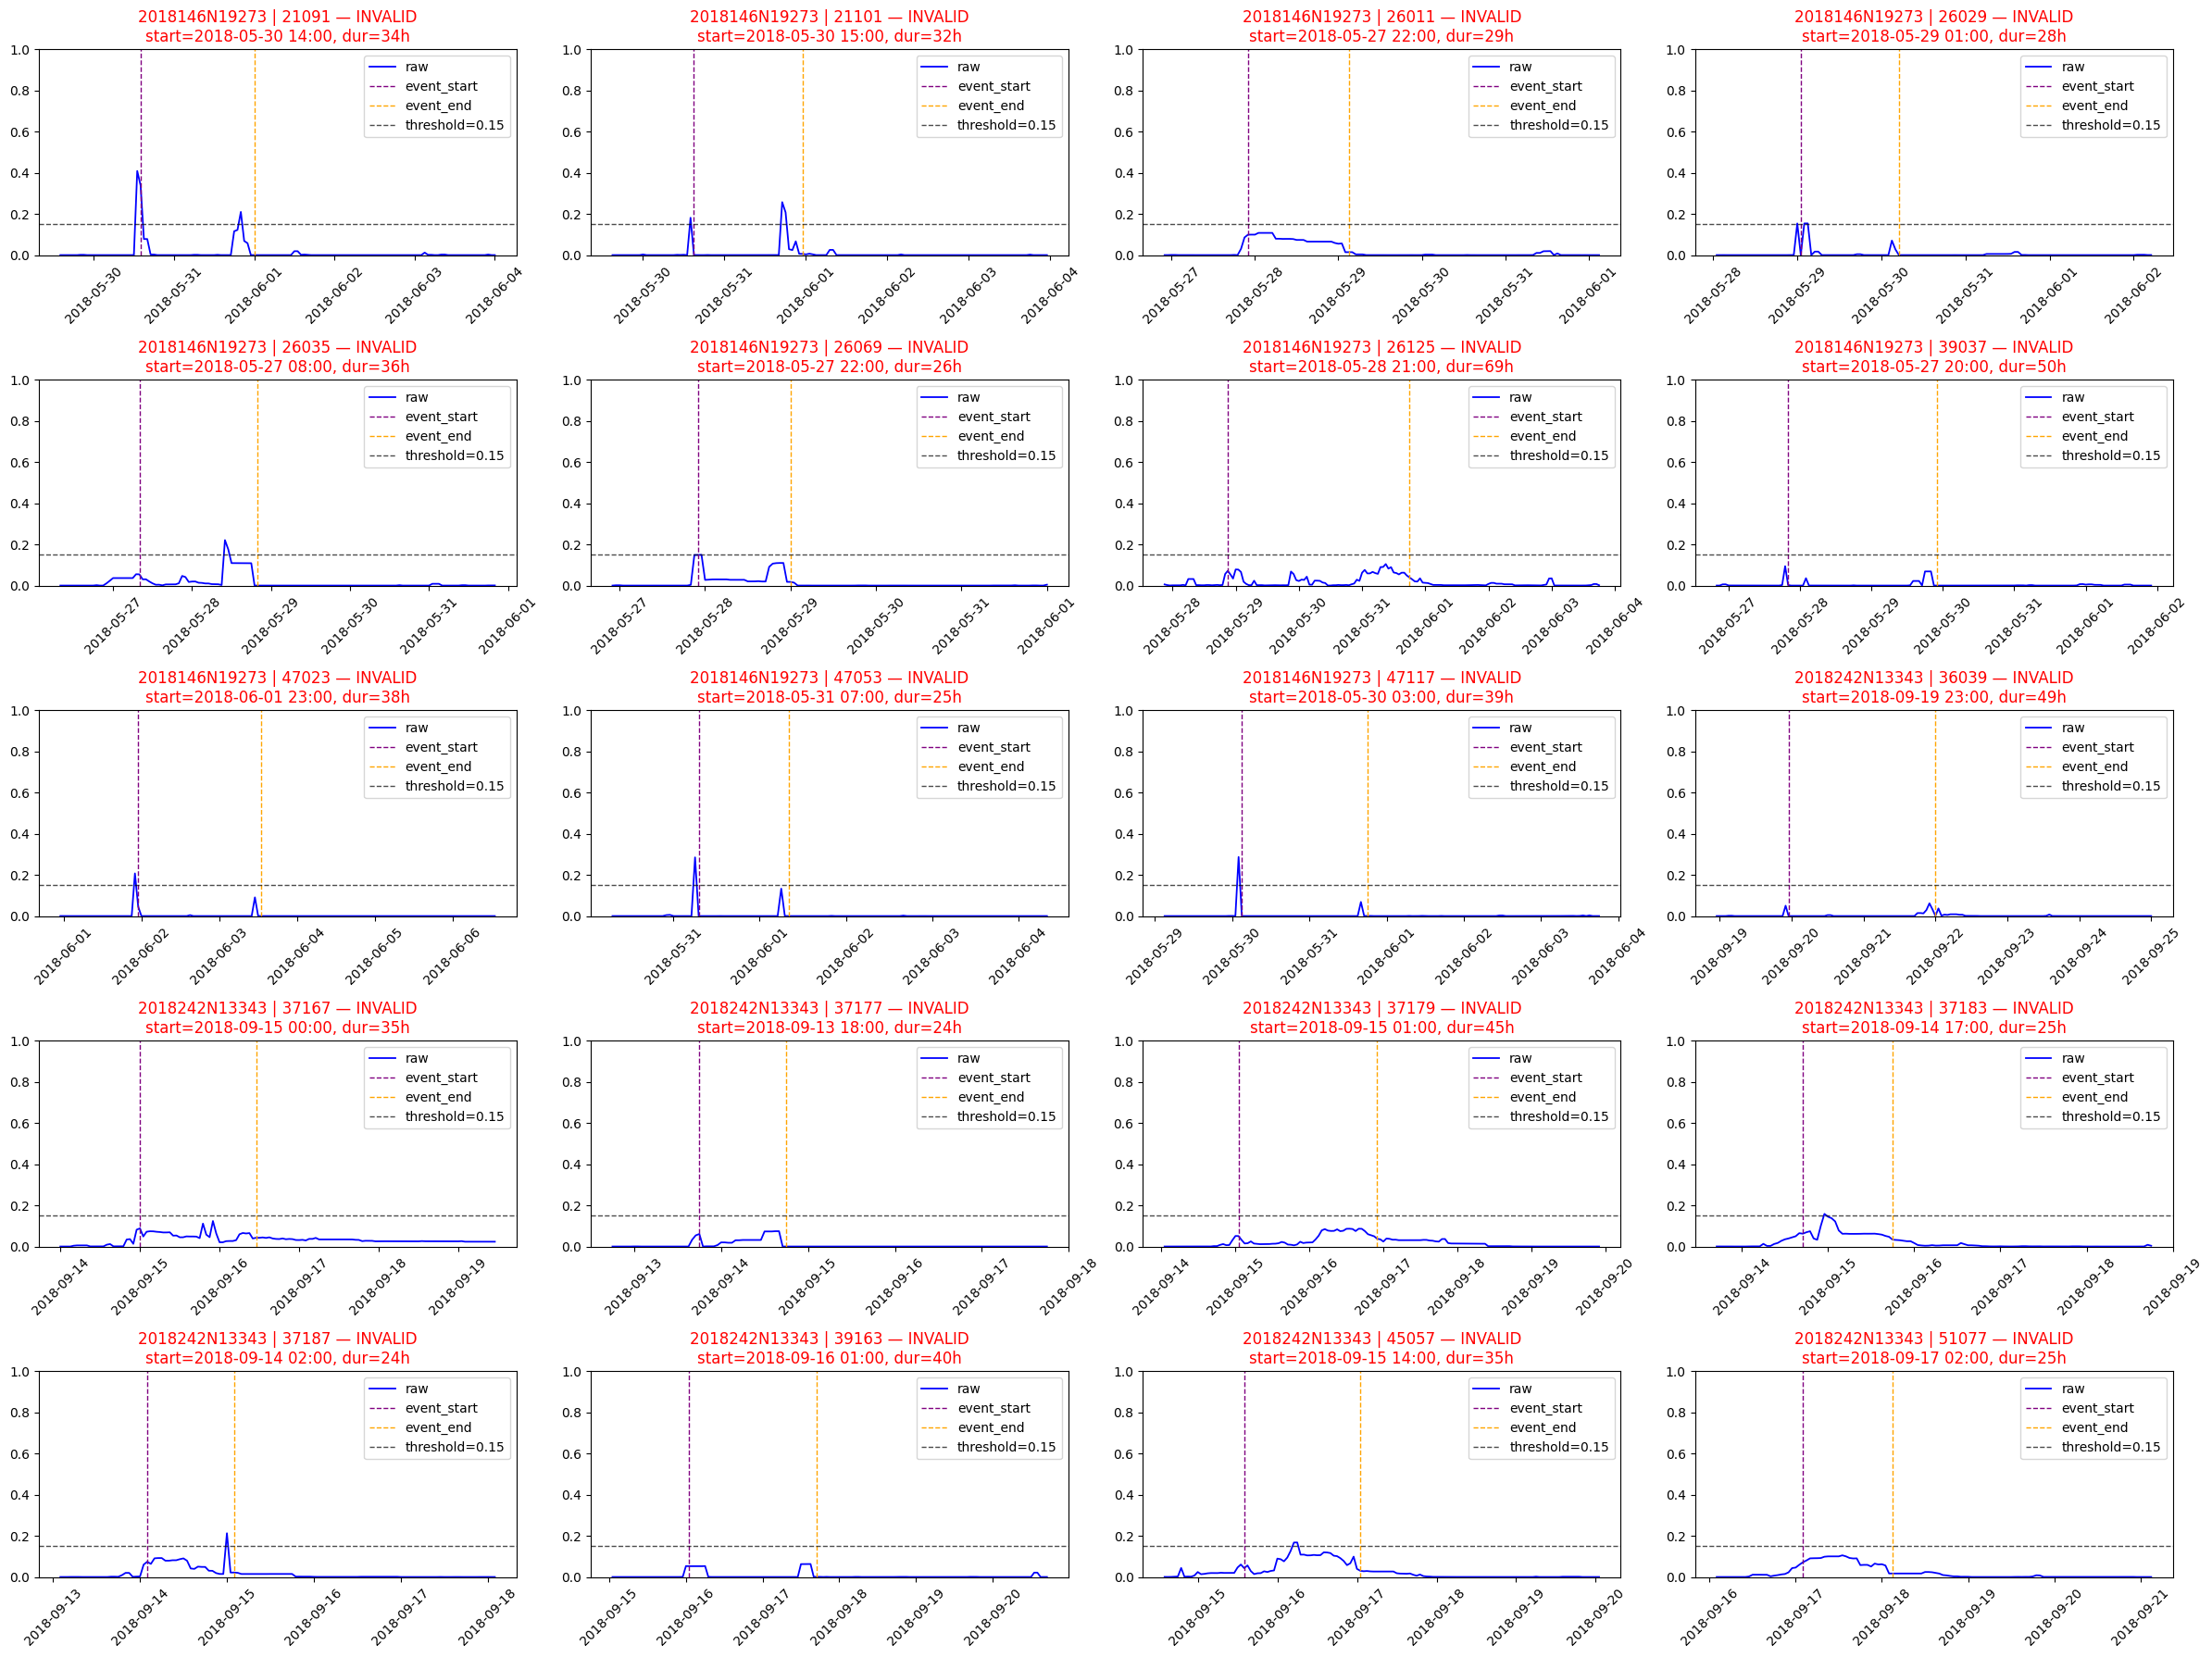

Plotted 20 invalid events out of 227 total rejected events.


In [18]:
# --- Cell 2: Plot rejected / invalid events in chunks (raw outageFraction) ---

import matplotlib.pyplot as plt

# Chunk controls which 20 plots are shown
plots_per_chunk = 20
chunk = 3

# Sort rejected events in a stable order
rejected = rejected.sort_values(["storm", "CountyFIPS", "event_start"]).reset_index(drop=True)

start = (chunk - 1) * plots_per_chunk
end = min(start + plots_per_chunk, len(rejected))
subset = rejected.iloc[start:end]

fig, axes = plt.subplots(5, 4, figsize=(24, 18))
axes = axes.ravel()

for ax in axes:
    ax.set_visible(False)

for ax, (_, row) in zip(axes, subset.iterrows()):
    county_fips = row["CountyFIPS"]
    event_start = row["event_start"]
    duration_hours = row["duration_hours"]
    event_end = event_start + pd.Timedelta(hours=float(duration_hours))

    # Give the plot a bit of context before and after the event window
    g = load_event_window_from_pq(
        county_fips=county_fips,
        event_start=event_start,
        event_end=event_end,
        pad_before_days=1,
        pad_after_days=3
    )

    ax.set_visible(True)
    ax.set_ylim(0.0, 1.0)

    if g.empty:
        ax.set_title(f"{row['event_id']} | {county_fips}\n(no data returned)")
        continue

    ax.plot(g["RecordDateTime"], g["OutageFraction"], color="blue", linewidth=1.3, label="raw")
    ax.axvline(event_start, color="purple", linestyle="--", linewidth=1, label="event_start")
    ax.axvline(event_end, color="orange", linestyle="--", linewidth=1, label="event_end")
    ax.axhline(peak_thresh, linestyle="--", linewidth=1, color="black", alpha=0.7, label=f"threshold={peak_thresh}")

    ax.set_title(
        f"{row['storm']} | {county_fips} — INVALID\n"
        f"start={event_start.strftime('%Y-%m-%d %H:%M')}, dur={duration_hours:.0f}h",
        color = "red"
    )
    ax.tick_params(axis="x", labelrotation=45)
    ax.legend(loc="best")

plt.tight_layout()
plt.show()

print(f"Plotted {len(subset)} invalid events out of {len(rejected)} total rejected events.")

^ that above logic was taken from *filtering_of.ipynb* 
- The below t90 target construction logic was taken from *regression5.ipynb*

In [19]:
# --- Cell: Helpers for CONUS t90 target construction (no t50 yet) ---

import pandas as pd
import numpy as np
from tqdm.auto import tqdm

# Same validity / cleaning settings used in the Florida notebook
threshold = 0.1          # t90 threshold
peak_thresh = 0.15       # event validity threshold
min_hours_above = 5      # event validity duration rule

med_window = 5           # rolling median window for cleaning
max_short_run = 3        # interpolate only short anomalous runs
abs_dev_thresh = 0.15    # anomaly threshold floor
rel_dev_scale = 0.35     # anomaly threshold relative to local median

# Assumes these already exist from earlier cells in the notebook:
#   pous      -> POUS event-level dataframe
#   ts_dataset -> pyarrow dataset for the large timeseries.pq
#   ds        -> pyarrow.dataset module

# Standardise POUS fields
pous = pous.copy()
pous["CountyFIPS"] = pous["CountyFIPS"].astype(str).str.zfill(5)
pous["event_start"] = pd.to_datetime(pous["event_start"])
pous["event_id"] = (
    pous["CountyFIPS"].astype(str) + "_" +
    pous["event_start"].dt.strftime("%Y-%m-%d %H:%M:%S")
)

def load_event_window_from_pq(county_fips, event_start, event_end):
    """
    Load the exact county-event window from the large parquet time series.
    """
    event_start = pd.Timestamp(event_start)
    event_end = pd.Timestamp(event_end)

    filt = (
        (ds.field("CountyFIPS") == county_fips) &
        (ds.field("RecordDateTime") >= event_start.to_pydatetime()) &
        (ds.field("RecordDateTime") <= event_end.to_pydatetime())
    )

    cols = ["RecordDateTime", "CountyFIPS", "OutageFraction"]
    available_cols = [c for c in cols if c in ts_dataset.schema.names]

    table = ts_dataset.to_table(columns=available_cols, filter=filt)
    out = table.to_pandas()

    if out.empty:
        return out

    # Parquet may reconstruct index-like columns depending on how it was written
    if "RecordDateTime" not in out.columns or "CountyFIPS" not in out.columns:
        out = out.reset_index()

    out["RecordDateTime"] = pd.to_datetime(out["RecordDateTime"])
    out["CountyFIPS"] = out["CountyFIPS"].astype(str).str.zfill(5)
    out = out.sort_values("RecordDateTime").reset_index(drop=True)

    return out

def clean_valid_outage_series(g):
    """
    Same cleaning logic as the Florida notebook, adapted to CONUS time series.
    Returns the dataframe with:
      - of_rolling_median
      - of_anomaly
      - of_short_anomaly
      - outageFraction_repaired
      - outage_clean
      - outageFraction_was_interpolated
    """
    g = g.sort_values("RecordDateTime").copy().reset_index(drop=True)
    s = g["OutageFraction"].astype(float).clip(0, 1)

    # 5-hour rolling median baseline
    med = s.rolling(window=med_window, center=True, min_periods=1).median()

    # Local deviation threshold: max(floor, relative)
    dev = (s - med).abs()
    thresh = np.maximum(abs_dev_thresh, rel_dev_scale * med)
    anomaly = dev > thresh

    # Identify anomalous runs
    run_id = (anomaly != anomaly.shift()).cumsum()
    run_len = anomaly.groupby(run_id).transform("sum")
    short_anom = anomaly & (run_len <= max_short_run)

    # Interpolate only short anomalous runs
    repaired = s.mask(short_anom, np.nan)
    repaired_filled = repaired.copy()
    was_interpolated = pd.Series(False, index=g.index)

    run_id_np = run_id.to_numpy()
    short_run_ids = pd.unique(run_id[short_anom])

    for rid in short_run_ids:
        pos = np.flatnonzero(run_id_np == rid)
        if len(pos) == 0 or len(pos) > max_short_run:
            continue

        left = pos[0] - 1
        right = pos[-1] + 1
        if left < 0 or right >= len(g):
            continue

        left_val = repaired.iloc[left]
        right_val = repaired.iloc[right]
        if pd.isna(left_val) or pd.isna(right_val):
            continue

        repaired_filled.iloc[pos] = np.linspace(left_val, right_val, len(pos) + 2)[1:-1]
        was_interpolated.iloc[pos] = True

    # Final light smoothing
    cleaned = repaired_filled.rolling(window=med_window, center=True, min_periods=1).median()

    g["of_rolling_median"] = med
    g["of_anomaly"] = anomaly
    g["of_short_anomaly"] = short_anom
    g["outageFraction_repaired"] = repaired_filled
    g["outage_clean"] = cleaned
    g["outageFraction_clean"] = cleaned   # alias for convenience / compatibility
    g["outageFraction_was_interpolated"] = was_interpolated

    return g

def last_downward_transition(g, threshold=0.1):
    """
    Compute the last downward crossing of outage_clean below threshold after event_start.
    Returns:
      - cross_time (Timestamp or None)
      - t_hours (float)
      - censored (0/1)
    """
    g = g.sort_values("RecordDateTime").copy()
    start = g["event_start"].iloc[0]

    post = g[g["RecordDateTime"] >= start].copy()
    y = post["outage_clean"].to_numpy(dtype=float)
    t = post["RecordDateTime"].to_numpy()

    if len(y) < 2:
        return None, 0.0, 1

    above_to_below = (y[:-1] > threshold) & (y[1:] <= threshold)
    idx = np.where(above_to_below)[0]

    if len(idx) == 0:
        # no downward crossing after event start
        return None, g["duration_hours"].iloc[0], 1

    i = idx[-1]  # last downward transition
    y0, y1 = y[i], y[i + 1]
    t0 = pd.Timestamp(t[i])
    t1 = pd.Timestamp(t[i + 1])

    if y0 == y1:
        cross_time = t1
    else:
        frac = (y0 - threshold) / (y0 - y1)
        cross_time = t0 + (t1 - t0) * frac

    t_hours = (cross_time - start) / pd.Timedelta(hours=1)
    return cross_time, float(t_hours), 0

In [ ]:
# --- Cell : Build the CONUS t90 event-level target table (valid events only) ---

from tqdm.auto import tqdm

t90_rows = []
rejected_rows = []

# Iterate through the full POUS table row-by-row using column access
for _, row in tqdm(pous.iterrows(), total=len(pous), desc="Building t90 targets"):
    county_fips = str(row["CountyFIPS"]).zfill(5)
    event_start = pd.Timestamp(row["event_start"])
    duration_hours = float(row["duration_hours"])
    event_end = event_start + pd.Timedelta(hours=duration_hours)

    # Load the exact event window from the large time series
    g_raw = load_event_window_from_pq(county_fips, event_start, event_end)
    g_raw["event_start"] = event_start
    g_raw["duration_hours"] = duration_hours

    if g_raw.empty:
        rejected_rows.append({
            "event_id": row["event_id"],
            "CountyFIPS": county_fips,
            "storm": row["storm"],
            "event_start": event_start,
            "event_end": event_end,
            "duration_hours": duration_hours,
            "reason": "no_time_series_data"
        })
        continue

    # Raw validity metrics
    s_raw = g_raw["OutageFraction"].astype(float).clip(0, 1)
    max_outage = float(s_raw.max())
    hours_above_thresh = int((s_raw > peak_thresh).sum())

    is_valid = (max_outage >= peak_thresh) and (hours_above_thresh >= min_hours_above)

    if not is_valid:
        rejected_rows.append({
            "event_id": row["event_id"],
            "CountyFIPS": county_fips,
            "storm": row["storm"],
            "event_start": event_start,
            "event_end": event_end,
            "duration_hours": duration_hours,
            "max_outage": max_outage,
            "hours_above_thresh": hours_above_thresh,
            "reason": "invalid_event"
        })
        continue

    # Clean valid event and compute t90
    g_clean = clean_valid_outage_series(g_raw)
    peak_outage_clean = float(g_clean["outage_clean"].max())

    cross_time, t90_val, censored = last_downward_transition(g_clean, threshold=threshold) # t90 threshold

    t90_rows.append({
        "event_id": row["event_id"],
        "CountyFIPS": county_fips,
        "storm": row["storm"],
        "event_start": event_start,
        "event_end": event_end,
        "duration_hours": duration_hours,
        "year": int(row["year"]),
        "month": int(row["month"]),
        "county_pop": int(row["county_pop"]),
        "pre_outage_tracked_customers": float(row["pre_outage_tracked_customers"]),
        "days_since_data_start": float(row["days_since_data_start"]),
        "n_periods": int(row["n_periods"]),
        "integral": float(row["integral"]),
        "pop_hours_supply_lost": float(row["pop_hours_supply_lost"]),
        "max_outage_raw": max_outage,
        "hours_above_thresh_raw": hours_above_thresh,
        "is_valid": True,
        "peak_outage_clean": peak_outage_clean,
        "threshold_used_t90": threshold, # t90 threshold
        "t90_lastcross": t90_val,
        "censored_lastcross": censored,
        "crossing_time_lastcross": cross_time,
    })

t90_targets = pd.DataFrame(t90_rows)
rejected_events = pd.DataFrame(rejected_rows)

print("t90 target table shape:", t90_targets.shape)
print("Rejected events shape:", rejected_events.shape)

print("\nValid event summary:")
print(t90_targets["t90_lastcross"].describe())

print("\nCensored fraction:")
print(t90_targets["censored_lastcross"].mean())

print("\nRejected by reason:")
if not rejected_events.empty:
    print(rejected_events["reason"].value_counts())
else:
    print("None")

Building t90 targets: 100%|██████████| 1040/1040 [00:56<00:00, 18.44it/s]

t90 target table shape: (813, 22)
Rejected events shape: (227, 9)

Valid event summary:
count    813.000000
mean      84.686152
std       97.643067
min        0.978131
25%       30.002041
50%       55.191589
75%       98.219389
max      680.559693
Name: t90_lastcross, dtype: float64

Censored fraction:
0.05289052890528905

Rejected by reason:
reason
invalid_event    227
Name: count, dtype: int64


In [26]:
# --- Cell : Save a versioned master base dataset for later feature expansion ---

# This is the traceable event-level base table:
# - one row per valid county-event
# - includes POUS metadata
# - includes t90 target
# - ready for later feature merges (GDP, distance, infrastructure, etc.)

master_base = t90_targets.merge(
    pous.drop(columns=["event_id"]),  # avoid duplicate event_id from the original POUS table
    on=["CountyFIPS", "storm", "event_start", "duration_hours", "year", "month",
        "county_pop", "pre_outage_tracked_customers", "days_since_data_start",
        "n_periods", "integral", "pop_hours_supply_lost"],
    how="left",
    suffixes=("", "_pous")
)

print("Master base shape:", master_base.shape)
print(master_base.head())

# Save outputs
base_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_master_base_t90_conus.csv"
rejected_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\rejected_events_t90_conus.csv"

master_base.to_csv(base_path, index=False)
rejected_events.to_csv(rejected_path, index=False)

print("\nSaved master base to:")
print(base_path)

print("\nSaved rejected events to:")
print(rejected_path)

Master base shape: (813, 23)
                    event_id CountyFIPS          storm         event_start  \
0  54059_2017-06-24 04:00:00      54059  2017171N24271 2017-06-24 04:00:00   
1  48355_2017-08-25 21:00:00      48355  2017228N14314 2017-08-25 21:00:00   
2  48391_2017-08-25 22:00:00      48391  2017228N14314 2017-08-25 22:00:00   
3  48409_2017-08-25 22:00:00      48409  2017228N14314 2017-08-25 22:00:00   
4  48239_2017-08-26 00:00:00      48239  2017228N14314 2017-08-26 00:00:00   

            event_end  duration_hours  year  month  county_pop  \
0 2017-06-26 18:00:00            62.0  2017      6       22573   
1 2017-09-04 22:00:00           241.0  2017      8      351674   
2 2017-09-11 23:00:00           409.0  2017      8        6632   
3 2017-09-07 01:00:00           291.0  2017      8       69954   
4 2017-09-02 04:00:00           172.0  2017      8       15142   

   pre_outage_tracked_customers  ...  pop_hours_supply_lost  max_outage_raw  \
0                       13

In [27]:
print("POUS columns:", pous.columns.tolist())
print("POUS dtypes:\n", pous.dtypes)
print("POUS head:\n", pous.head(1).T)

POUS columns: ['event_start', 'CountyFIPS', 'county_pop', 'pre_outage_tracked_customers', 'days_since_data_start', 'duration_hours', 'n_periods', 'integral', 'pop_hours_supply_lost', 'storm', 'duration_days', 'year', 'month', 'event_id']
POUS dtypes:
 event_start                     datetime64[us]
CountyFIPS                                 str
county_pop                               int64
pre_outage_tracked_customers           float64
days_since_data_start                  float64
duration_hours                           int64
n_periods                                int64
integral                               float64
pop_hours_supply_lost                  float64
storm                                      str
duration_days                          float64
year                                     int64
month                                    int64
event_id                                   str
dtype: object
POUS head:
                                                       0
event_st

In [28]:
print("g_raw shape:", g_raw.shape)
print("g_raw columns:", g_raw.columns.tolist())
print("g_raw dtypes:\n", g_raw.dtypes)
print("g_raw head:\n", g_raw.head())
print("g_raw index:", type(g_raw.index), getattr(g_raw.index, "names", None))

g_raw shape: (58, 5)
g_raw columns: ['RecordDateTime', 'CountyFIPS', 'OutageFraction', 'event_start', 'duration_hours']
g_raw dtypes:
 RecordDateTime    datetime64[ns]
CountyFIPS                   str
OutageFraction           float64
event_start       datetime64[us]
duration_hours           float64
dtype: object
g_raw head:
        RecordDateTime CountyFIPS  OutageFraction         event_start  \
0 2022-10-01 02:00:00      51590        0.325578 2022-10-01 02:00:00   
1 2022-10-01 03:00:00      51590        0.365634 2022-10-01 02:00:00   
2 2022-10-01 04:00:00      51590        0.395865 2022-10-01 02:00:00   
3 2022-10-01 05:00:00      51590        0.422155 2022-10-01 02:00:00   
4 2022-10-01 06:00:00      51590        0.422155 2022-10-01 02:00:00   

   duration_hours  
0            57.0  
1            57.0  
2            57.0  
3            57.0  
4            57.0  
g_raw index: <class 'pandas.RangeIndex'> [None]


In [29]:
print("After adding metadata columns:")
print(g_raw[["event_start", "duration_hours"]].head())

After adding metadata columns:
          event_start  duration_hours
0 2022-10-01 02:00:00            57.0
1 2022-10-01 02:00:00            57.0
2 2022-10-01 02:00:00            57.0
3 2022-10-01 02:00:00            57.0
4 2022-10-01 02:00:00            57.0


In [30]:
print("ts_dataset schema names:", ts_dataset.schema.names)

ts_dataset schema names: ['OutageFraction', 'CustomersTracked', 'RecordDateTime', 'CountyFIPS']


Now adding t50, using logic from *adding_t50.ipynb* (which was only for Florida, but should be generalizable to CONUS)

In [33]:
# --- Cell: Add t50 to the CONUS event-level target table ---

# This uses the same cleaning / last-crossing logic as t90,
# but defines t50 relative to each event's own peak outage_clean:
#   threshold_50 = 0.5 * max(outage_clean after event_start)

t50_rows = []

# Use the already-built valid event table if it exists;
# otherwise fall back to POUS rows.
base_events = (
    t90_targets[["event_id", "CountyFIPS", "storm", "event_start", "event_end", "duration_hours"]]
    .drop_duplicates()
    .copy()
)

for _, row in tqdm(base_events.iterrows(), total=len(base_events), desc="Building t50 targets"):
    county_fips = str(row["CountyFIPS"]).zfill(5)
    event_start = pd.Timestamp(row["event_start"])
    event_end = pd.Timestamp(row["event_end"])
    duration_hours = float(row["duration_hours"])

    # Load raw time series for the event window
    g_raw = load_event_window_from_pq(county_fips, event_start, event_end)
    if g_raw.empty:
        t50_rows.append({
            "event_id": row["event_id"],
            "CountyFIPS": county_fips,
            "t50": np.nan,
            "t50_censored": 1,
            "peak_outage_clean": np.nan,
            "threshold_used_t50": np.nan,
            "crossing_time_t50": pd.NaT,
        })
        continue

    # Attach metadata expected by the helper
    g_raw["event_start"] = event_start
    g_raw["duration_hours"] = duration_hours

    # Clean the event
    g_clean = clean_valid_outage_series(g_raw)

    # Peak defined after cleaning, after event_start
    post = g_clean[g_clean["RecordDateTime"] >= event_start].copy()
    peak = post["outage_clean"].max()

    if pd.isna(peak) or peak <= 0:
        t50 = np.nan
        cens50 = 1
        cross_time_50 = pd.NaT
        threshold_50 = np.nan
    else:
        threshold_50 = 0.5 * float(peak)
        cross_time_50, t50, cens50 = last_downward_transition(g_clean, threshold=threshold_50)

    t50_rows.append({
        "event_id": row["event_id"],
        "CountyFIPS": county_fips,
        "t50": t50,
        "t50_censored": cens50,
        "peak_outage_clean": float(peak) if pd.notna(peak) else np.nan,
        "threshold_used_t50": threshold_50,
        "crossing_time_t50": cross_time_50,
    })

t50_df = pd.DataFrame(t50_rows)

print("t50 table shape:", t50_df.shape)
print(t50_df.head())

# Merge onto the existing t90 target table
targets_df = t90_targets.merge(
    t50_df,
    on=["event_id", "CountyFIPS"],
    how="left"
)

# Clean up duplicated peak column after merge
targets_df["peak_outage_clean"] = targets_df["peak_outage_clean_x"]
targets_df = targets_df.drop(columns=["peak_outage_clean_x", "peak_outage_clean_y"])

print(targets_df[[
    "event_id", "CountyFIPS", "t90_lastcross", "t50", "peak_outage_clean"
]].head())

print("\nMerged target table shape:", targets_df.shape)
print(targets_df[[
    "event_id", "CountyFIPS", "t90_lastcross", "t50", "peak_outage_clean"
]].head())

print("\nMissing t50 count:", targets_df["t50"].isna().sum())
print("t50 censored fraction:", targets_df["t50_censored"].mean())

Building t50 targets:   0%|          | 0/813 [00:00<?, ?it/s]

Building t50 targets: 100%|██████████| 813/813 [01:01<00:00, 13.14it/s]

t50 table shape: (813, 7)
                    event_id CountyFIPS         t50  t50_censored  \
0  54059_2017-06-24 04:00:00      54059   11.327241             0   
1  48355_2017-08-25 21:00:00      48355   76.333549             0   
2  48391_2017-08-25 22:00:00      48391  260.913793             0   
3  48409_2017-08-25 22:00:00      48409  122.136965             0   
4  48239_2017-08-26 00:00:00      48239  127.699095             0   

   peak_outage_clean  threshold_used_t50             crossing_time_t50  
0           0.475376            0.237688 2017-06-24 15:19:38.066037735  
1           0.732856            0.366428 2017-08-29 01:20:00.775694893  
2           0.989056            0.494528 2017-09-05 18:54:49.655172413  
3           0.906812            0.453406 2017-08-31 00:08:13.072448439  
4           0.775962            0.387981 2017-08-31 07:41:56.742081447  
                    event_id CountyFIPS  t90_lastcross         t50  \
0  54059_2017-06-24 04:00:00      54059      12.655

^ It means that about 1.42% of the valid county-event cases did not cross below the t50 threshold within the observed time window, so t50 was treated as censored for those events. This is not great, and it stems from the fact that t90 is using an absolute threshold (10% of customers still out), which is more likely to be crossed than a relative threshold like 50% of the peak outage. **This should likely be changed in the future.**

To extract the weather data in GEE, I need a csv like FL_POUS.csv but for CONUS. 


In [34]:
# --- Cell: Build CONUS_POUS.csv from the raw POUS event table ---
# Input: raw POUS event table
pous_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_raw\POUS.csv"
# Output: CONUS POUS event table to upload **as a GEE asset**
save_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\CONUS_POUS.csv"

import pandas as pd


# Load raw POUS
pous = pd.read_csv(pous_path)

# Standardize key fields
pous["CountyFIPS"] = pous["CountyFIPS"].astype(str).str.zfill(5)
pous["event_start"] = pd.to_datetime(pous["event_start"])

# Recreate event_id if needed, but keep the same convention used before
if "event_id" not in pous.columns:
    pous["event_id"] = (
        pous["CountyFIPS"].astype(str) + "_" +
        pous["event_start"].dt.strftime("%Y-%m-%d %H:%M:%S")
    )

# Ensure the output uses the same column order as the Florida file
wanted_cols = [
    "event_start",
    "CountyFIPS",
    "county_pop",
    "pre_outage_tracked_customers",
    "days_since_data_start",
    "duration_hours",
    "n_periods",
    "integral",
    "pop_hours_supply_lost",
    "storm",
    "duration_days",
    "year",
    "month",
    "event_id",
]

missing = [c for c in wanted_cols if c not in pous.columns]
if missing:
    raise KeyError(f"Missing expected columns in POUS table: {missing}")

conus_pous = pous[wanted_cols].copy()

# Save
conus_pous.to_csv(save_path, index=False)

print("Saved CONUS_POUS.csv to:")
print(save_path)
print("\nShape:", conus_pous.shape)
print("\nHead:")
print(conus_pous.head().to_string(index=False))

Saved CONUS_POUS.csv to:
C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\CONUS_POUS.csv

Shape: (1040, 14)

Head:
        event_start CountyFIPS  county_pop  pre_outage_tracked_customers  days_since_data_start  duration_hours  n_periods  integral  pop_hours_supply_lost         storm  duration_days  year  month                  event_id
2017-06-21 16:00:00      54001       15414                        6599.0             171.625000              47         47  0.389301           6.000692e+03 2017171N24271       1.958333  2017      6 54001_2017-06-21 16:00:00
2017-06-24 04:00:00      54059       22573                       13970.0             174.125000              62         62  4.778789           1.078716e+05 2017171N24271       2.583333  2017      6 54059_2017-06-24 04:00:00
2017-07-30 21:00:00      12075       45260                        2942.7             210.833333              86         86  4.007550           1.813817e+05 2017212N28275       3.583333  2017

(Made conus_pilot_gee_era5.js to extract the weather data for CONUS, using the input CSV above.) 

The output from that GEE pilot script is at data_transients\conus_pous_era5_hourly_pilot.csv . 

In [ ]:
# check the pilot script to see if that worked okay.
import pandas as pd

fl_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\florida_all_events_era5_hourly.csv"
conus_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\conus_pous_era5_hourly_pilot.csv"

fl = pd.read_csv(fl_path, nrows=5)
conus = pd.read_csv(conus_path, nrows=5)

print("Florida columns:")
print(fl.columns.tolist())

print("\nCONUS columns:")
print(conus.columns.tolist())

print("\nShared columns only:")
shared = [c for c in fl.columns if c in conus.columns]
print(shared)

print("\nFlorida sample:")
print(fl.head().to_string(index=False))

print("\nCONUS sample:")
print(conus.head().to_string(index=False))

Florida columns:
['system:index', 'county', 'datetime', 'duration_hours', 'event_id', 'event_start', 'geoid', 'gust_mps', 'precip_mm', 'pressure_hpa', 'storm', 'temp_c', 'wind_speed_mps', '.geo']

CONUS columns:
['system:index', 'county', 'datetime', 'duration_hours', 'event_id', 'event_start', 'geoid', 'gust_mps', 'precip_mm', 'pressure_hpa', 'storm', 'temp_c', 'wind_speed_mps', '.geo']

Shared columns only:
['system:index', 'county', 'datetime', 'duration_hours', 'event_id', 'event_start', 'geoid', 'gust_mps', 'precip_mm', 'pressure_hpa', 'storm', 'temp_c', 'wind_speed_mps', '.geo']

Florida sample:
                    system:index county         datetime  duration_hours                  event_id         event_start  geoid  gust_mps  precip_mm  pressure_hpa         storm    temp_c  wind_speed_mps                                   .geo
00000000000000000000_20170730T09   Levy 2017-07-30 09:00              86 12075_2017-07-30 21:00:00 2017-07-30 21:00:00  12075  9.834633   1.732711   10

^ Seems to have worked fine!

So, now for the full data export rather than just a pilot snippet. GEE code in conus_full_gee_era5.js . This will produce *data_transients\conus_pous_era5_hourly.csv* .